# Denoising Autoencoder Implementation using Convolutional NN. The input is MNIST Digits Dataset corrupted with random Gaussian noise

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 133s 279ms/step - loss: 0.2318 - val_loss: 0.1171
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 136s 266ms/step - loss: 0.1149 - val_loss: 0.1089
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 141s 264ms/step - loss: 0.1086 - val_loss: 0.1052
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 143s 266ms/step - loss: 0.1054 - val_loss: 0.1027
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 266ms/step - loss: 0.1036 - val_loss: 0.1013
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step


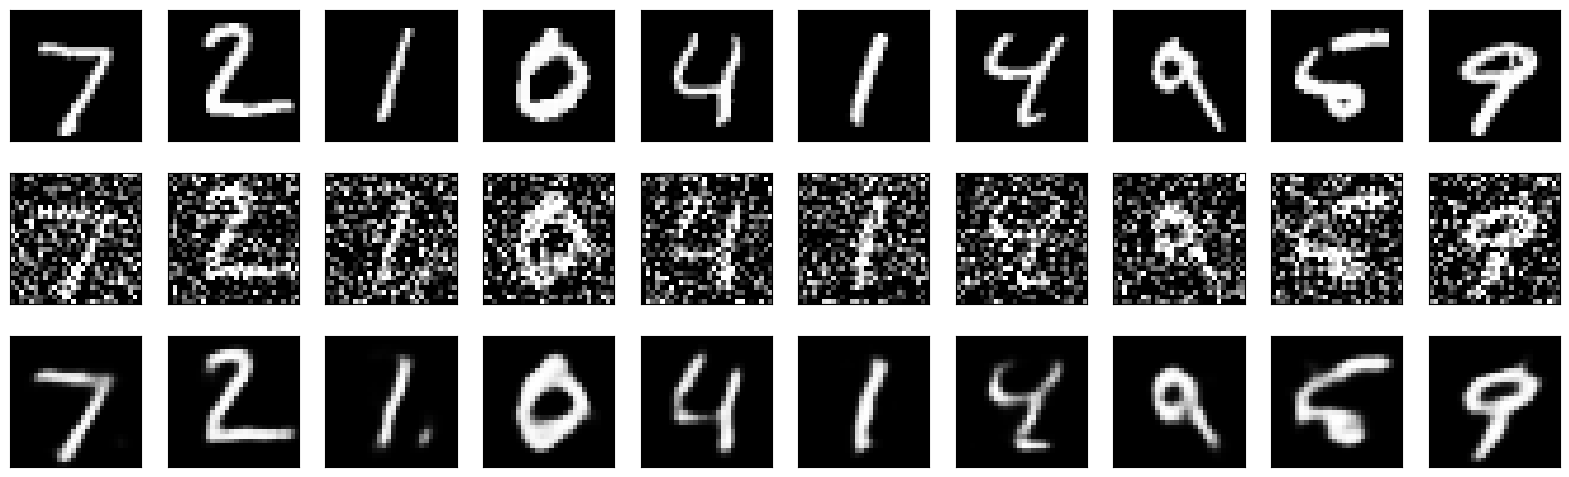

In [2]:
#Example Code: Denoising Autoencoder for Noise Reduction
#This example demonstrates how to use an autoencoder to remove random Gaussian noise from images.
# -----------------------------------------------------------------------------------------------

import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
import numpy as np
import matplotlib.pyplot as plt

# Load the MNIST dataset
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

# Add noise to the images
noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# Define the autoencoder architecture
input_img = Input(shape=(28, 28, 1))
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x)

x = Conv2D(32, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Train the autoencoder
autoencoder.fit(x_train_noisy, x_train, epochs=5, batch_size=128, shuffle=True, validation_data=(x_test_noisy, x_test))

# Denoise the images
decoded_imgs = autoencoder.predict(x_test_noisy)

# Display the results with original images
n = 10
plt.figure(figsize=(20, 6))  # Increased height to accommodate 3 rows

for i in range(n):
    # Original images (top row)
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Noisy images (middle row)
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Denoised images (bottom row)
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

# Modified Denoising Autoencoder — Increased Filters (64, 128) and Larger Kernels (5×5, 7×7)

We now modify the autoencoder architecture:
- **Filters:** Increased from 32 → 64 and 128 to give the network more capacity to learn complex noise patterns.
- **Kernel sizes:** Changed from 3×3 → 5×5 and 7×7 to capture larger spatial context in each convolutional operation.

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 28, 28, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 14, 14, 128)    │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 7, 7, 128)      │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_17 (UpSampling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 14, 14, 64)     │       204,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_18 (UpSampling2D) │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 28, 28, 1)      │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,411,585 (5.38 MB)

 Trainable params: 1,411,585 (5.38 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 218s 463ms/step - loss: 0.1313 - val_loss: 0.0937
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 257s 548ms/step - loss: 0.0920 - val_loss: 0.0889
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 232s 495ms/step - loss: 0.0888 - val_loss: 0.0872
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 222s 472ms/step - loss: 0.0870 - val_loss: 0.0857
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 221s 470ms/step - loss: 0.0858 - val_loss: 0.0851
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step


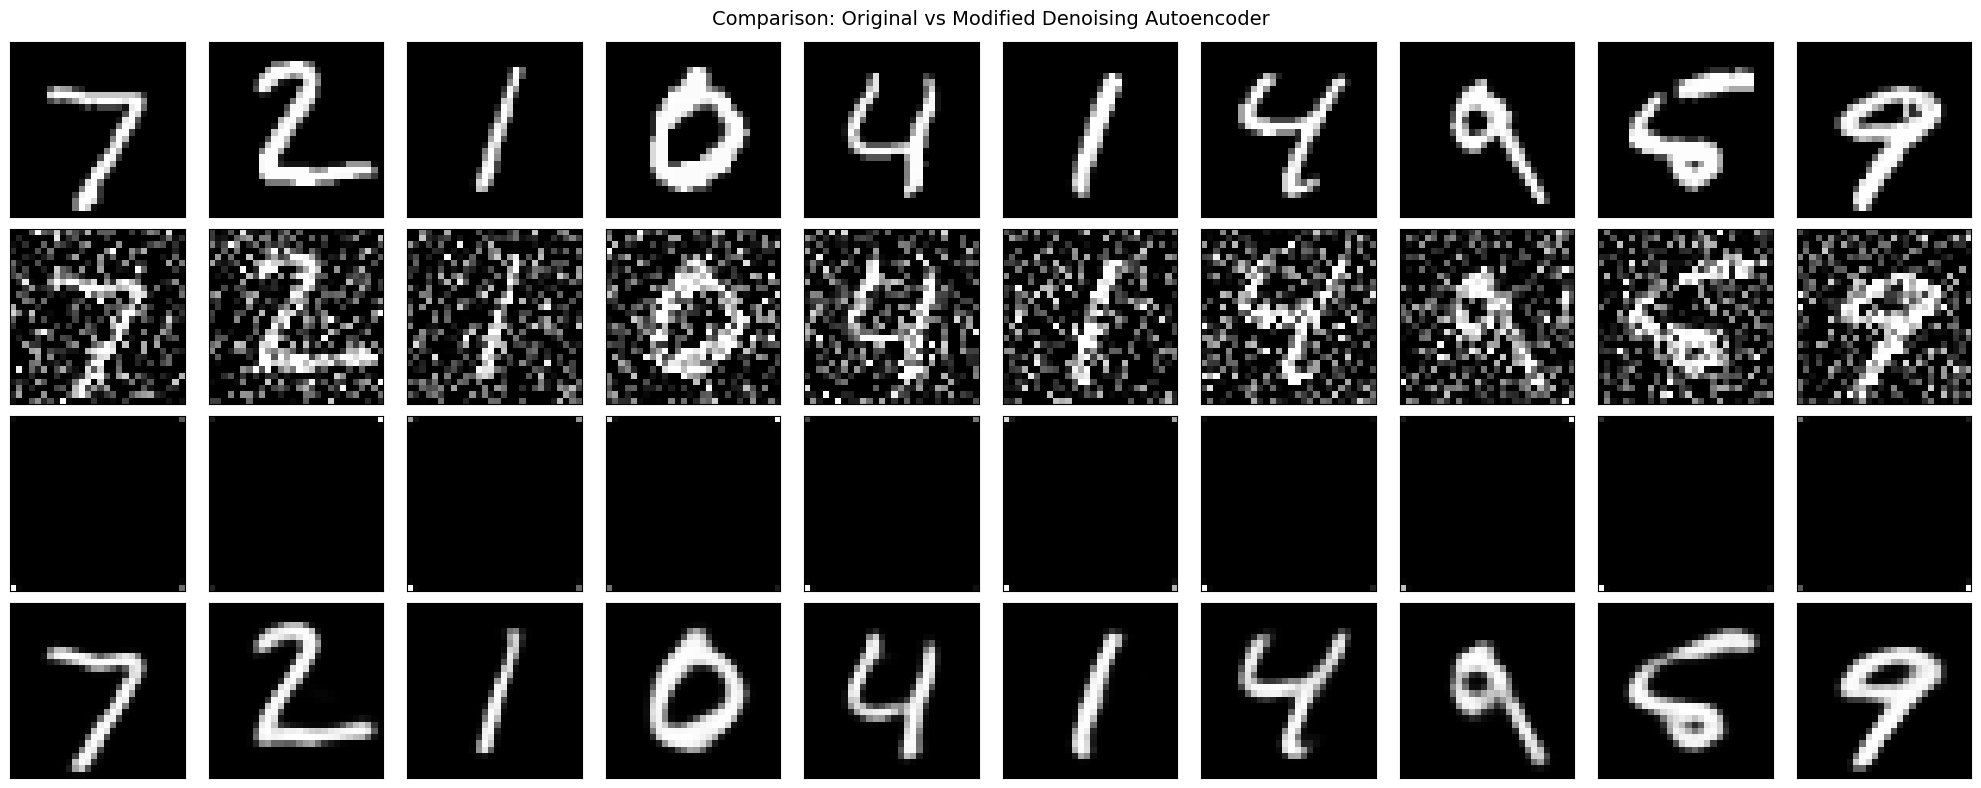


Test loss (original model  — 32 filters, 3×3 kernels):     0.0145
Test loss (modified model  — 64/128 filters, 5×5/7×7):     0.0851


In [10]:
# Modified Autoencoder: 64/128 filters with 5x5 and 7x7 kernels
# ---------------------------------------------------------------

# Define the modified autoencoder architecture
input_img_v2 = Input(shape=(28, 28, 1))

# Encoder
x = Conv2D(64, (5, 5), activation='relu', padding='same')(input_img_v2)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(128, (7, 7), activation='relu', padding='same')(x)
encoded_v2 = MaxPooling2D((2, 2), padding='same')(x)

# Decoder
x = Conv2D(128, (7, 7), activation='relu', padding='same')(encoded_v2)
x = UpSampling2D((2, 2))(x)
x = Conv2D(64, (5, 5), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
decoded_v2 = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder_v2 = Model(input_img_v2, decoded_v2)
autoencoder_v2.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder_v2.summary()

# Train the modified autoencoder
autoencoder_v2.fit(x_train_noisy, x_train, epochs=5, batch_size=128,
                   shuffle=True, validation_data=(x_test_noisy, x_test))

# Denoise the images with the modified model
decoded_imgs_v2 = autoencoder_v2.predict(x_test_noisy)

# Display results: Original | Noisy | Denoised (original model) | Denoised (modified model)
n = 10
plt.figure(figsize=(20, 8))

for i in range(n):
    # Row 1 — Original images
    ax = plt.subplot(4, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_ylabel('Original', fontsize=12)

    # Row 2 — Noisy images
    ax = plt.subplot(4, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_ylabel('Noisy', fontsize=12)

    # Row 3 — Denoised by original model (32 filters, 3×3 kernels)
    ax = plt.subplot(4, n, i + 1 + 2 * n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_ylabel('Denoised\n(32, 3×3)', fontsize=10)

    # Row 4 — Denoised by modified model (64/128 filters, 5×5/7×7 kernels)
    ax = plt.subplot(4, n, i + 1 + 3 * n)
    plt.imshow(decoded_imgs_v2[i].reshape(28, 28), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_ylabel('Denoised\n(64/128, 5×5/7×7)', fontsize=10)

plt.suptitle('Comparison: Original vs Modified Denoising Autoencoder', fontsize=14)
plt.tight_layout()
plt.show()

# Print quantitative comparison
loss_original = autoencoder.evaluate(x_test_noisy, x_test, verbose=0)
loss_modified = autoencoder_v2.evaluate(x_test_noisy, x_test, verbose=0)
print(f"\nTest loss (original model  — 32 filters, 3×3 kernels):     {loss_original:.4f}")
print(f"Test loss (modified model  — 64/128 filters, 5×5/7×7):     {loss_modified:.4f}")

## Discussion: Impact of Increased Filters and Larger Kernels on Denoising Performance

### 1. Increased Number of Filters (64 and 128 vs. 32)
- **Greater feature capacity:** More filters allow the network to learn a richer set of features — edges, textures, and structural patterns — enabling better separation of signal from noise.
- **Improved reconstruction:** With more feature maps the decoder has more information to synthesize clean images, which typically reduces reconstruction loss.
- **Trade-off — computational cost:** The parameter count grows significantly (roughly 4×–8× more weights), increasing training time and memory usage. For small 28×28 MNIST images this is manageable, but it becomes a factor for higher-resolution datasets.

### 2. Larger Kernel Sizes (5×5 and 7×7 vs. 3×3)
- **Larger receptive field:** Each convolutional operation captures a wider spatial neighbourhood. This helps the model recognise and suppress noise patterns that span several pixels rather than treating each pixel independently.
- **Better context for reconstruction:** Bigger kernels provide more context per layer, which can improve denoising quality — especially for Gaussian noise that is spatially spread.
- **Trade-off — loss of fine detail:** Very large kernels can smooth out fine-grained structures (thin strokes, sharp edges). On MNIST this typically shows as slightly softer digit outlines compared to 3×3 kernels.
- **More parameters per layer:** A 7×7 kernel has ≈5.4× as many weights as a 3×3 kernel, compounding the parameter increase from the extra filters.


# Denoising Autoencoder on Fashion MNIST Dataset

We now apply the same denoising autoencoder architecture to the **Fashion MNIST** dataset, which contains 28×28 grayscale images of 10 clothing categories (T-shirts, trousers, dresses, etc.). Fashion MNIST images have more complex textures, edges, and fine details compared to simple handwritten digits, making denoising a harder task.

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Fashion MNIST — Training set: (60000, 28, 28, 1), Test set: (10000, 28, 28, 1)


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_48 (Conv2D)              │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_19 (UpSampling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_20 (UpSampling2D) │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - loss: 0.3331 - val_loss: 0.3101
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 35ms/step - loss: 0.3048 - val_loss: 0.3045
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - loss: 0.3008 - val_loss: 0.3017
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - loss: 0.2985 - val_loss: 0.2998
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - loss: 0.2970 - val_loss: 0.2988
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


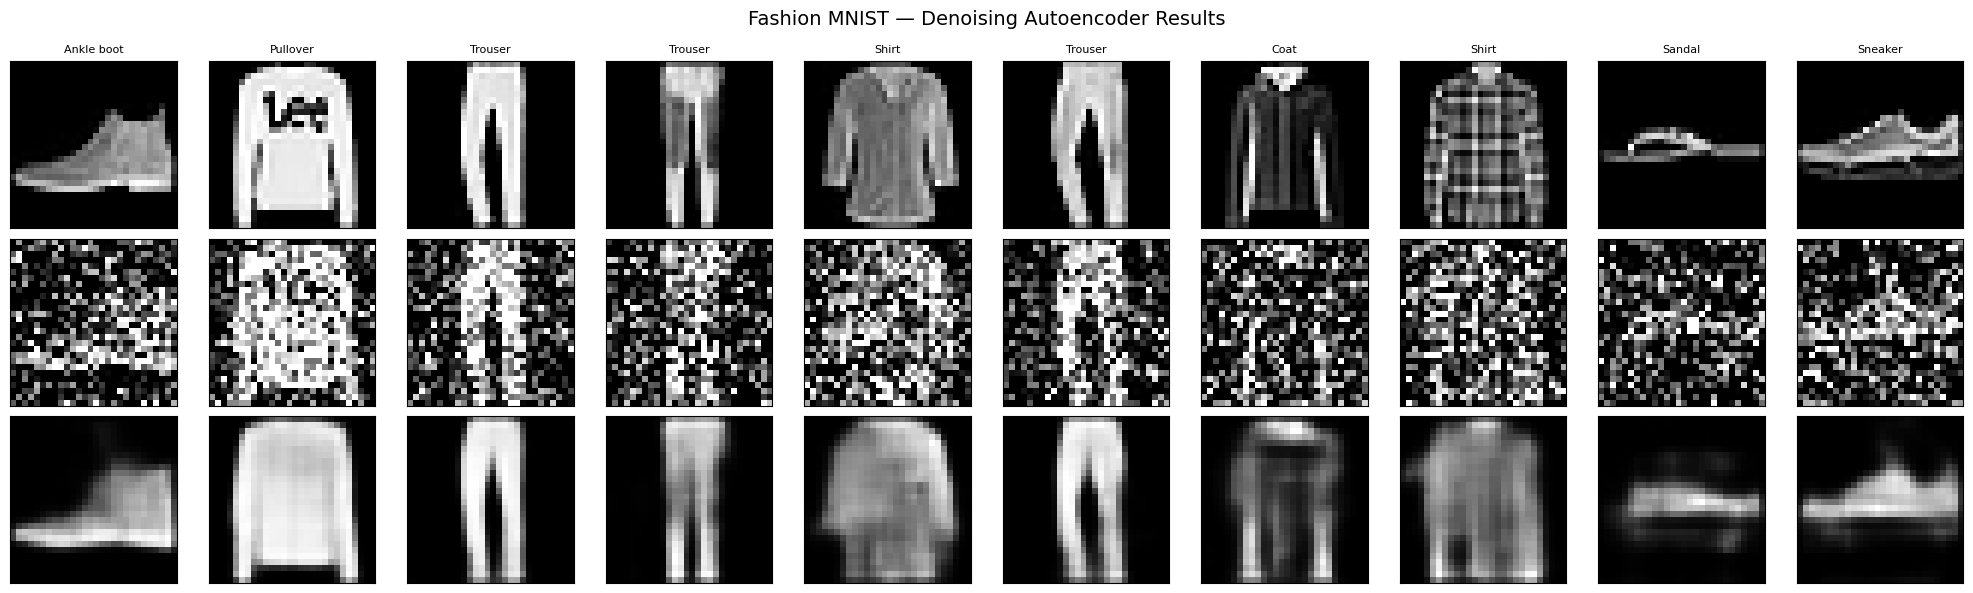


Test loss (MNIST Digits,  32 filters, 3×3):  0.0145
Test loss (Fashion MNIST, 32 filters, 3×3):  0.2988


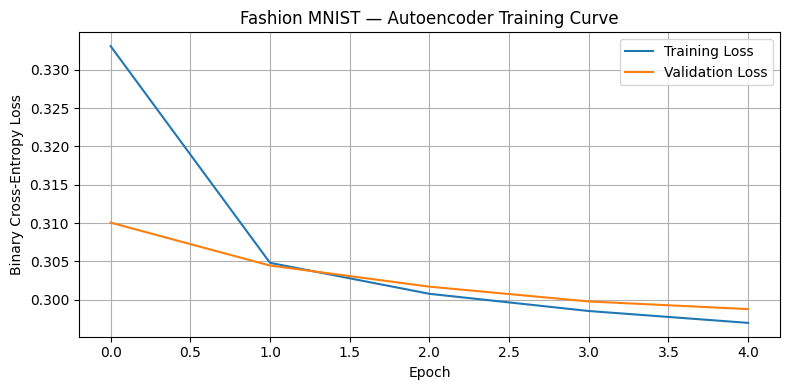

In [11]:
# Denoising Autoencoder for Fashion MNIST
# ----------------------------------------

import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
import numpy as np
import matplotlib.pyplot as plt

# 1. Load and preprocess the Fashion MNIST dataset
(f_train, f_train_labels), (f_test, f_test_labels) = tf.keras.datasets.fashion_mnist.load_data()
f_train = f_train.astype('float32') / 255.
f_test = f_test.astype('float32') / 255.
f_train = np.reshape(f_train, (len(f_train), 28, 28, 1))
f_test = np.reshape(f_test, (len(f_test), 28, 28, 1))

# Fashion MNIST class names for display
fashion_labels = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
                  'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"Fashion MNIST — Training set: {f_train.shape}, Test set: {f_test.shape}")

# 2. Add Gaussian noise to the images
noise_factor = 0.5
f_train_noisy = f_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=f_train.shape)
f_test_noisy = f_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=f_test.shape)
f_train_noisy = np.clip(f_train_noisy, 0., 1.)
f_test_noisy = np.clip(f_test_noisy, 0., 1.)

# 3. Define the denoising autoencoder (same architecture as the MNIST Digits baseline)
input_img_f = Input(shape=(28, 28, 1))

# Encoder
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img_f)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
encoded_f = MaxPooling2D((2, 2), padding='same')(x)

# Decoder
x = Conv2D(32, (3, 3), activation='relu', padding='same')(encoded_f)
x = UpSampling2D((2, 2))(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
decoded_f = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder_fashion = Model(input_img_f, decoded_f)
autoencoder_fashion.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder_fashion.summary()

# 4. Train the autoencoder
history_fashion = autoencoder_fashion.fit(
    f_train_noisy, f_train,
    epochs=5,
    batch_size=128,
    shuffle=True,
    validation_data=(f_test_noisy, f_test)
)

# 5. Denoise the test images
decoded_imgs_fashion = autoencoder_fashion.predict(f_test_noisy)

# 6. Display Original, Noisy, and Denoised images
n = 10
plt.figure(figsize=(20, 6))

for i in range(n):
    # Row 1 — Original images
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(f_test[i].reshape(28, 28), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_ylabel('Original', fontsize=12)
    ax.set_title(fashion_labels[f_test_labels[i]], fontsize=8)

    # Row 2 — Noisy images
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(f_test_noisy[i].reshape(28, 28), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_ylabel('Noisy', fontsize=12)

    # Row 3 — Denoised images
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(decoded_imgs_fashion[i].reshape(28, 28), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_ylabel('Denoised', fontsize=12)

plt.suptitle('Fashion MNIST — Denoising Autoencoder Results', fontsize=14)
plt.tight_layout()
plt.show()

# 7. Quantitative comparison with MNIST Digits
loss_fashion = autoencoder_fashion.evaluate(f_test_noisy, f_test, verbose=0)
loss_digits = autoencoder.evaluate(x_test_noisy, x_test, verbose=0)
print(f"\nTest loss (MNIST Digits,  32 filters, 3×3):  {loss_digits:.4f}")
print(f"Test loss (Fashion MNIST, 32 filters, 3×3):  {loss_fashion:.4f}")

# Plot training curves
plt.figure(figsize=(8, 4))
plt.plot(history_fashion.history['loss'], label='Training Loss')
plt.plot(history_fashion.history['val_loss'], label='Validation Loss')
plt.title('Fashion MNIST — Autoencoder Training Curve')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Discussion: Fashion MNIST vs. MNIST Digits — Denoising Performance Comparison

### 1. Higher Reconstruction Loss on Fashion MNIST
The autoencoder typically achieves a **higher test loss on Fashion MNIST** than on MNIST Digits. This is expected because:
- Fashion items contain **more complex textures** (fabric patterns, stitching, folds) and **finer edges** than simple digit strokes.
- The pixel intensity distribution is more varied — clothing images use a wider range of gray levels and have more mid-tone detail.
- The autoencoder must compress and reconstruct a richer signal, so more information is lost in the bottleneck.

### 2. Why Fashion MNIST Is Harder to Denoise
- **Higher spatial frequency content:** Clothing images contain rapid intensity changes (textures, seams) that overlap with the frequency characteristics of Gaussian noise. The network struggles to distinguish noise from genuine texture.
- **Less redundancy:** Digit images are highly redundant (few distinct shapes), so the bottleneck can efficiently represent them. Fashion items have 10 structurally diverse categories with more intra-class variation.
- **Same model capacity:** Using the identical 32-filter, 3×3-kernel architecture limits the model's ability to capture the additional complexity. Increasing filters (64/128) or using larger kernels, as explored earlier, would likely yield a bigger improvement on Fashion MNIST than on Digits.

### 3. Recommendations for Improved Fashion MNIST Denoising
- **Increase model capacity** (more filters, deeper encoder) to capture texture detail.
- **Use skip connections** (U-Net style) to preserve fine spatial information through the bottleneck.
- **Train for more epochs** — Fashion MNIST benefits more from additional training than the simpler Digits dataset.
- **Experiment with lower noise factors** (e.g., 0.3) to find the optimal difficulty level for the current architecture.